## Week 5 Assignment

In [1]:
# Import the libraries required for the analysis

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the Job Survey CSV file

df = pd.read_csv("data/job_survey_data.csv")

# Display the first five records
df.head()


,id,ethnicgp,gender,income,age,years,commit,satis1,satis2,satis3,...,autonom4,routine1,routine2,routine3,routine4,attend,skill,prody,qual,absence
0,1,1,1,16600,29,1,4,0,3,4,...,2,2,2,3,2,2,3,0,1,7
1,2,2,1,14600,26,1,2,0,0,2,...,2,3,4,4,4,1,3,4,4,8
2,3,3,1,17800,40,5,4,4,4,4,...,2,2,1,2,3,1,4,3,4,0
3,4,3,1,16400,46,15,2,2,1,2,...,2,3,2,2,3,2,3,3,4,4
4,5,2,2,18600,63,36,4,3,4,4,...,3,4,5,5,4,1,3,5,3,0


In [3]:
# Check the number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display all variable names
print("\nVariable names:")
print(df.columns.tolist())

Number of rows: 70
Number of columns: 24

Variable names:
['id', 'ethnicgp', 'gender', 'income', 'age', 'years', 'commit', 'satis1', 'satis2', 'satis3', 'satis4', 'autonom1', 'autonom2', 'autonom3', 'autonom4', 'routine1', 'routine2', 'routine3', 'routine4', 'attend', 'skill', 'prody', 'qual', 'absence']


In [4]:
# Examine the data type of each variable

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 24 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        70 non-null     int64
 1   ethnicgp  70 non-null     int64
 2   gender    70 non-null     int64
 3   income    70 non-null     int64
 4   age       70 non-null     int64
 5   years     70 non-null     int64
 6   commit    70 non-null     int64
 7   satis1    70 non-null     int64
 8   satis2    70 non-null     int64
 9   satis3    70 non-null     int64
 10  satis4    70 non-null     int64
 11  autonom1  70 non-null     int64
 12  autonom2  70 non-null     int64
 13  autonom3  70 non-null     int64
 14  autonom4  70 non-null     int64
 15  routine1  70 non-null     int64
 16  routine2  70 non-null     int64
 17  routine3  70 non-null     int64
 18  routine4  70 non-null     int64
 19  attend    70 non-null     int64
 20  skill     70 non-null     int64
 21  prody     70 non-null     int64
 22  qual

In [5]:
# Count missing values in each variable

missing_values = df.isnull().sum()

print(missing_values)

id          0
ethnicgp    0
gender      0
income      0
age         0
years       0
commit      0
satis1      0
satis2      0
satis3      0
satis4      0
autonom1    0
autonom2    0
autonom3    0
autonom4    0
routine1    0
routine2    0
routine3    0
routine4    0
attend      0
skill       0
prody       0
qual        0
absence     0
dtype: int64


In [6]:
# Count duplicated rows in the dataset

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [7]:
# Produce descriptive statistics for absence

df["absence"].describe()


count    70.000000
mean      5.957143
std      11.803261
min       0.000000
25%       1.250000
50%       4.000000
75%       8.000000
max      99.000000
Name: absence, dtype: float64

In [8]:
# Calculate the median separately because describe() does not label it directly

absence_median = df["absence"].median()

print("Median absence:", absence_median)

Median absence: 4.0


In [9]:
# Count the number of employees for each absence value

absence_frequency = df["absence"].value_counts().sort_index()

print(absence_frequency)

absence
0     10
1      8
2      5
3      6
4      9
5      4
6      5
7      2
8      9
9      5
10     3
11     2
13     1
99     1
Name: count, dtype: int64


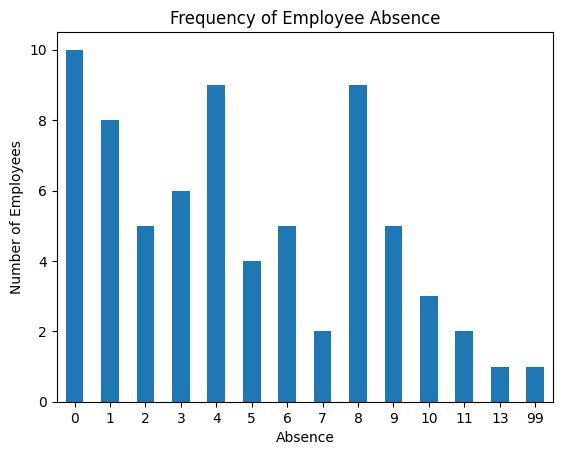

In [10]:
# Create a bar chart showing the frequency of each absence value

absence_frequency.plot(kind="bar")

plt.title("Frequency of Employee Absence")
plt.xlabel("Absence")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.show()

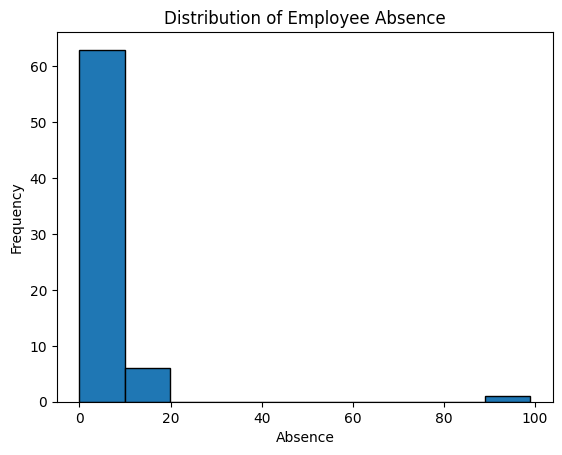

In [11]:
# Draw a histogram to examine the distribution of absence

df["absence"].plot(
    kind="hist",
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Employee Absence")
plt.xlabel("Absence")
plt.ylabel("Frequency")
plt.show()

<module 'matplotlib.pyplot' from 'd:\\Code\\dsc-shared\\Lib\\site-packages\\matplotlib\\pyplot.py'>

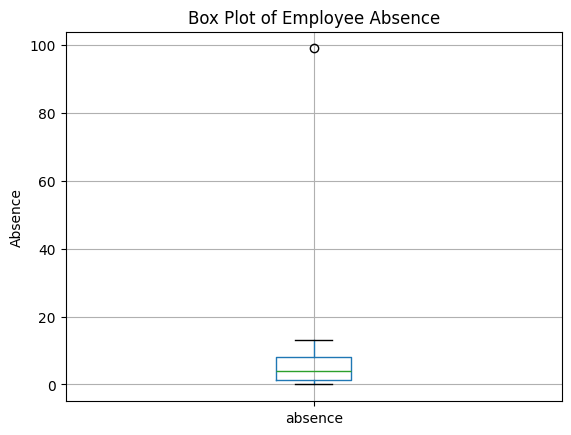

In [12]:
# Draw a box plot to identify possible extreme values

df.boxplot(column="absence")

plt.title("Box Plot of Employee Absence")
plt.ylabel("Absence")
plt

In [13]:
# Create a smaller dataset containing the four autonomy items

autonomy_columns = [
    "autonom1",
    "autonom2",
    "autonom3",
    "autonom4"
]

autonomy = df[autonomy_columns]

# Display the first five records
autonomy.head()


,autonom1,autonom2,autonom3,autonom4
0,2,4,2,2
1,2,2,1,2
2,2,1,2,2
3,1,2,2,2
4,2,3,3,3


In [14]:
# Examine the mean, standard deviation, minimum and maximum
# for each autonomy item

autonomy.describe()

,autonom1,autonom2,autonom3,autonom4
count,70.000000,70.000000,70.000000,70.000000
mean,2.414286,2.414286,2.328571,2.185714
std,0.892689,1.069916,0.880076,0.839131
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000
50%,2.000000,2.000000,2.000000,2.000000
75%,3.000000,3.000000,3.000000,3.000000
max,5.000000,5.000000,4.000000,4.000000


In [15]:
# Count missing responses for each autonomy item

autonomy.isnull().sum()

autonom1    0
autonom2    0
autonom3    0
autonom4    0
dtype: int64

In [16]:
# Display the frequency distribution of each autonomy item

for column in autonomy_columns:
    print("\nFrequency distribution for", column)
    print(df[column].value_counts().sort_index())


Frequency distribution for autonom1
autonom1
1     8
2    34
3    21
4     5
5     2
Name: count, dtype: int64

Frequency distribution for autonom2
autonom2
1    14
2    27
3    18
4     8
5     3
Name: count, dtype: int64

Frequency distribution for autonom3
autonom3
1    14
2    24
3    27
4     5
Name: count, dtype: int64

Frequency distribution for autonom4
autonom4
1    14
2    34
3    17
4     5
Name: count, dtype: int64


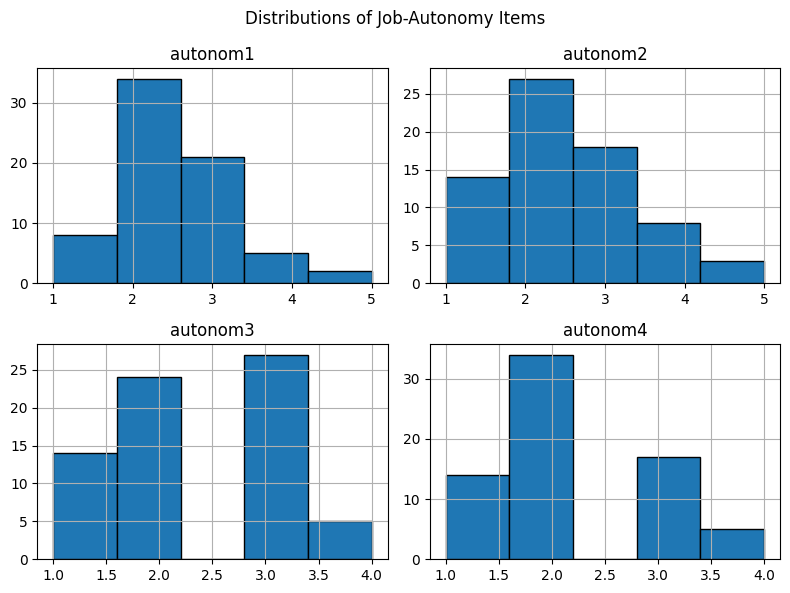

In [17]:
# Create separate histograms for the four autonomy items

autonomy.hist(
    bins=5,
    edgecolor="black",
    figsize=(8, 6)
)

plt.suptitle("Distributions of Job-Autonomy Items")
plt.tight_layout()
plt.show()

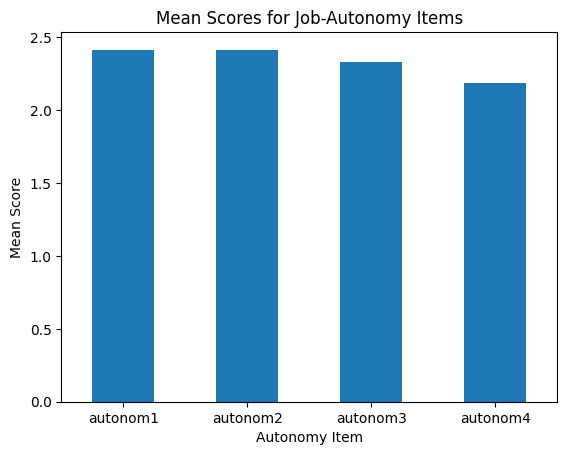

In [18]:
# Calculate and plot the mean of each autonomy item

autonomy_means = autonomy.mean()

autonomy_means.plot(kind="bar")

plt.title("Mean Scores for Job-Autonomy Items")
plt.xlabel("Autonomy Item")
plt.ylabel("Mean Score")
plt.xticks(rotation=0)
plt.show()

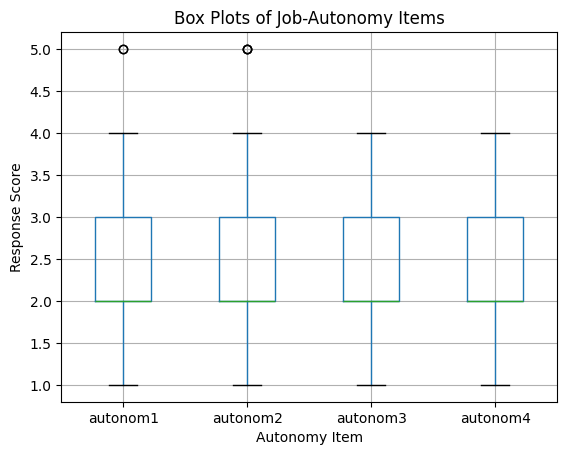

In [19]:
# Compare the distributions and possible extreme values
# across the four autonomy items

autonomy.boxplot()

plt.title("Box Plots of Job-Autonomy Items")
plt.xlabel("Autonomy Item")
plt.ylabel("Response Score")
plt.show()

In [20]:
# Calculate correlations between the four autonomy items

autonomy_correlation = autonomy.corr()

autonomy_correlation

,autonom1,autonom2,autonom3,autonom4
autonom1,1.000000,0.439830,0.414535,0.650346
autonom2,0.439830,1.000000,0.330477,0.381194
autonom3,0.414535,0.330477,1.000000,0.426415
autonom4,0.650346,0.381194,0.426415,1.000000


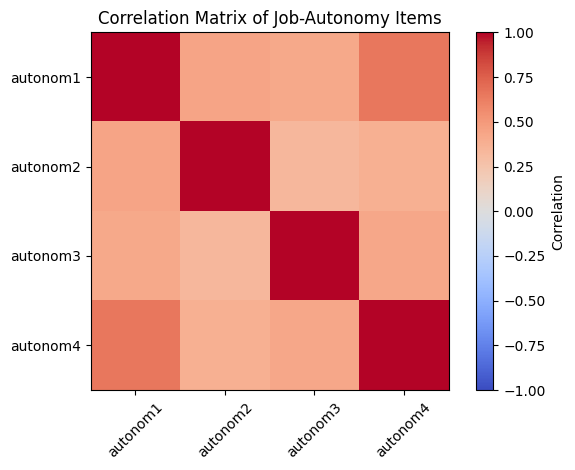

In [21]:
# Display the correlations between autonomy items as an image

plt.imshow(
    autonomy_correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(autonomy_columns)),
    autonomy_columns,
    rotation=45
)

plt.yticks(
    range(len(autonomy_columns)),
    autonomy_columns
)

plt.title("Correlation Matrix of Job-Autonomy Items")
plt.tight_layout()
plt.show()

In [22]:
# Remove rows with missing autonomy responses

autonomy_complete = autonomy.dropna()

# Count the number of autonomy items
number_of_items = autonomy_complete.shape[1]

# Calculate the variance of each individual item
item_variances = autonomy_complete.var(ddof=1)

# Create a total autonomy score for each participant
total_score = autonomy_complete.sum(axis=1)

# Calculate the variance of the total score
total_variance = total_score.var(ddof=1)

# Calculate Cronbach's alpha
cronbach_alpha = (
    number_of_items / (number_of_items - 1)
) * (
    1 - item_variances.sum() / total_variance
)

print("Cronbach's alpha:", round(cronbach_alpha, 3))

Cronbach's alpha: 0.75


In [23]:
# Calculate the corrected item-total correlation for each autonomy item

item_total_results = {}

for column in autonomy_columns:
    
    # Create a total score that excludes the current item
    remaining_items = autonomy_complete.drop(columns=column)
    remaining_total = remaining_items.sum(axis=1)
    
    # Correlate the current item with the remaining total score
    correlation = autonomy_complete[column].corr(remaining_total)
    
    item_total_results[column] = correlation

# Convert the results into a clear table
item_total_table = pd.Series(
    item_total_results,
    name="Corrected item-total correlation"
)

item_total_table

autonom1    0.646770
autonom2    0.471359
autonom3    0.476789
autonom4    0.620495
Name: Corrected item-total correlation, dtype: float64

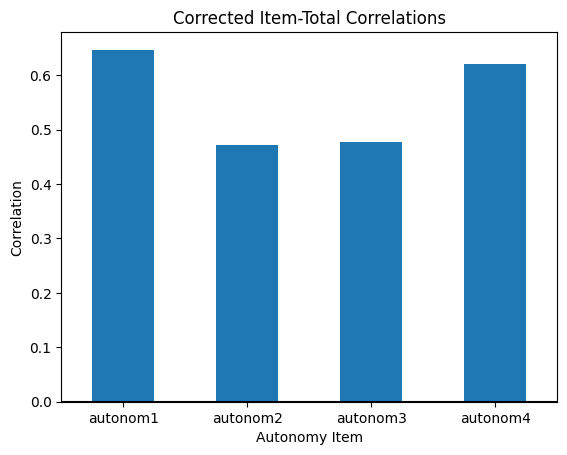

In [24]:
# Plot the corrected item-total correlations

item_total_table.plot(kind="bar")

plt.title("Corrected Item-Total Correlations")
plt.xlabel("Autonomy Item")
plt.ylabel("Correlation")
plt.xticks(rotation=0)
plt.axhline(0, color="black")
plt.show()

In [25]:
# Create an empty dictionary for the results

alpha_if_deleted = {}

# Calculate alpha after removing each autonomy item in turn
for removed_item in autonomy_columns:
    
    remaining_data = autonomy_complete.drop(columns=removed_item)
    
    number_of_items = remaining_data.shape[1]
    item_variances = remaining_data.var(ddof=1)
    total_score = remaining_data.sum(axis=1)
    total_variance = total_score.var(ddof=1)
    
    alpha = (
        number_of_items / (number_of_items - 1)
    ) * (
        1 - item_variances.sum() / total_variance
    )
    
    alpha_if_deleted[removed_item] = alpha

# Present the results as a table
alpha_deleted_table = pd.Series(
    alpha_if_deleted,
    name="Cronbach's alpha if deleted"
)

alpha_deleted_table.round(3)

autonom1    0.637
autonom2    0.747
autonom3    0.729
autonom4    0.656
Name: Cronbach's alpha if deleted, dtype: float64

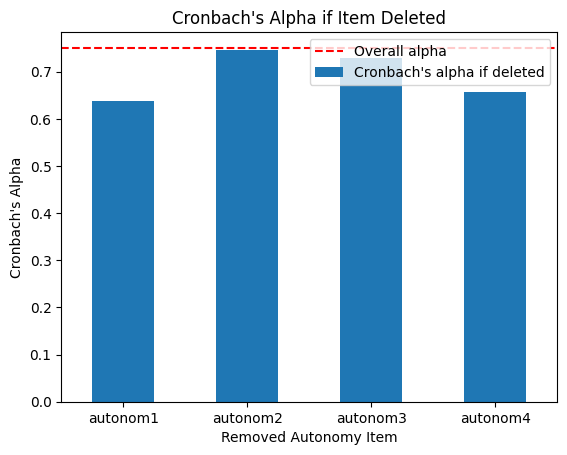

In [26]:
# Plot Cronbach's alpha if each item is removed

alpha_deleted_table.plot(kind="bar")

# Add a line showing the overall Cronbach's alpha
plt.axhline(
    cronbach_alpha,
    color="red",
    linestyle="--",
    label="Overall alpha"
)

plt.title("Cronbach's Alpha if Item Deleted")
plt.xlabel("Removed Autonomy Item")
plt.ylabel("Cronbach's Alpha")
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [27]:
# Calculate the average autonomy score for each participant

df["autonomy_mean"] = df[autonomy_columns].mean(axis=1)

# Examine the new autonomy score
df["autonomy_mean"].describe()

count    70.000000
mean      2.335714
std       0.699231
min       1.000000
25%       1.750000
50%       2.250000
75%       2.937500
max       4.000000
Name: autonomy_mean, dtype: float64

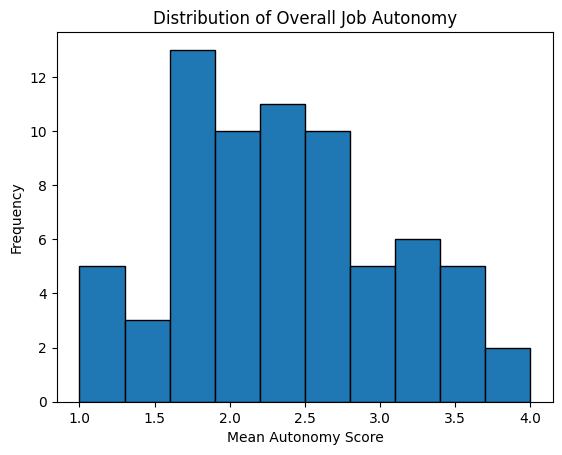

In [28]:
# Examine the distribution of the overall autonomy mean score

df["autonomy_mean"].plot(
    kind="hist",
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Overall Job Autonomy")
plt.xlabel("Mean Autonomy Score")
plt.ylabel("Frequency")
plt.show()